In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-job/job_cleanData.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [3]:
# loading the data 
job_data = pd.read_csv('/kaggle/input/data-job/job_cleanData.csv')
#checking the first 5 rows of the dataframe
job_data.head()

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,3471657636,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395547e+06,About the job Crossover is the world's #1 sour...,2697,IT Services and IT Consulting,Associate,Delhi,Delhi
1,3471669068,Data Analyst,524.0,Crossover,Remote,Full-time,1001,184,5.395547e+06,About the job Crossover is the world's #1 sour...,2724,IT Services and IT Consulting,Associate,New Delhi,Delhi
2,3474349934,Data Analyst,2242.0,Uplers,Remote,Full-time,1001,200,9.821152e+05,About the job Profile: ML EngineersExperience:...,3668,IT Services and IT Consulting,Mid-Senior level,Greater Bengaluru Area,Karnataka
3,3472816027,Data Analyst,1553.0,PVAR SERVICES,On-site,Full-time,1,200,2.094000e+03,About the job Designation: Data AnalystLocatio...,3083,Not Avilable,Not Avilable,Gurugram,Haryana
4,3473311511,Data Analyst,2147.0,Timeline Freight Brokers,On-site,Full-time,1,8,9.821152e+05,About the job The ideal candidate will use the...,3359,Not Avilable,Not Avilable,Mohali district,North West


In [4]:
job_data.shape

(5587, 15)

In [5]:
# getting some information about the dataset
job_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5587 entries, 0 to 5586
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_ID              5587 non-null   int64  
 1   designation         5587 non-null   object 
 2   company_id          5587 non-null   float64
 3   name                5587 non-null   object 
 4   work_type           5587 non-null   object 
 5   involvement         5587 non-null   object 
 6   employees_count     5587 non-null   int64  
 7   total_applicants    5587 non-null   int64  
 8   linkedin_followers  5587 non-null   float64
 9   job_details         5587 non-null   object 
 10  details_id          5587 non-null   int64  
 11  industry            5587 non-null   object 
 12  level               5587 non-null   object 
 13  City                5587 non-null   object 
 14  State               5587 non-null   object 
dtypes: float64(2), int64(4), object(9)
memory usage: 654.9+

In [6]:
job_data.isnull().sum()

job_ID                0
designation           0
company_id            0
name                  0
work_type             0
involvement           0
employees_count       0
total_applicants      0
linkedin_followers    0
job_details           0
details_id            0
industry              0
level                 0
City                  0
State                 0
dtype: int64

In [7]:
job_data.describe()

,job_ID,company_id,employees_count,total_applicants,linkedin_followers,details_id
count,5.587000e+03,5587.000000,5587.000000,5587.000000,5.587000e+03,5587.000000
mean,3.467219e+09,1165.662431,2119.530517,24.141758,9.834312e+05,2954.158403
std,6.189089e+07,696.076468,3512.711835,52.756793,2.232506e+06,1687.379838
min,1.419216e+08,1.000000,1.000000,0.000000,3.000000e+00,1.000000
25%,3.467374e+09,640.000000,51.000000,0.000000,1.810450e+04,1500.500000
50%,3.472553e+09,957.000000,1001.000000,0.000000,4.501680e+05,2975.000000
75%,3.476290e+09,1849.500000,1001.000000,16.000000,9.821152e+05,4422.500000
max,3.477823e+09,2494.000000,10001.000000,200.000000,1.313679e+07,5843.000000


In [8]:
sns.set()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


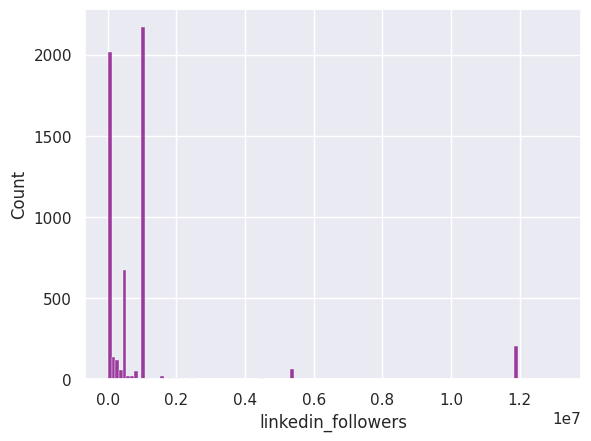

In [9]:

#plt.figure(figsize=(5,5))
sns.histplot(job_data['linkedin_followers'], color='purple')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


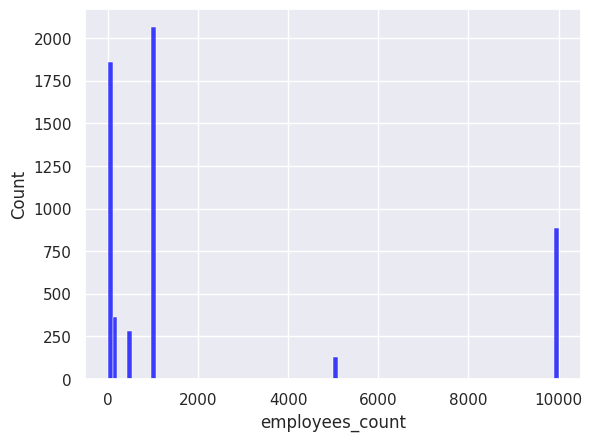

In [10]:
#plt.figure(figsize=(5,5))
sns.histplot(job_data['employees_count'], color='blue')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


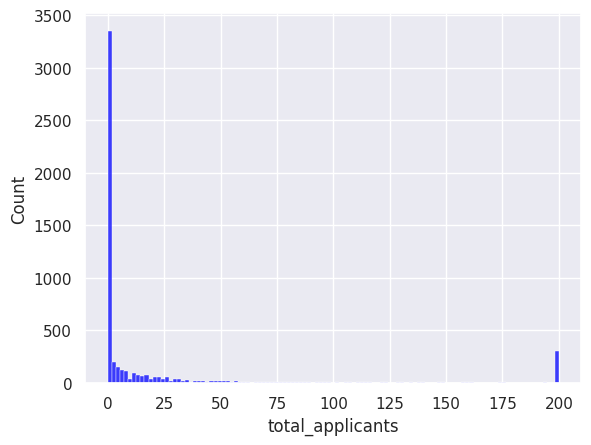

In [11]:
#plt.figure(figsize=(5,5))
sns.histplot(job_data['total_applicants'], color='blue')
plt.show()

In [12]:
job_data.head()

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,3471657636,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395547e+06,About the job Crossover is the world's #1 sour...,2697,IT Services and IT Consulting,Associate,Delhi,Delhi
1,3471669068,Data Analyst,524.0,Crossover,Remote,Full-time,1001,184,5.395547e+06,About the job Crossover is the world's #1 sour...,2724,IT Services and IT Consulting,Associate,New Delhi,Delhi
2,3474349934,Data Analyst,2242.0,Uplers,Remote,Full-time,1001,200,9.821152e+05,About the job Profile: ML EngineersExperience:...,3668,IT Services and IT Consulting,Mid-Senior level,Greater Bengaluru Area,Karnataka
3,3472816027,Data Analyst,1553.0,PVAR SERVICES,On-site,Full-time,1,200,2.094000e+03,About the job Designation: Data AnalystLocatio...,3083,Not Avilable,Not Avilable,Gurugram,Haryana
4,3473311511,Data Analyst,2147.0,Timeline Freight Brokers,On-site,Full-time,1,8,9.821152e+05,About the job The ideal candidate will use the...,3359,Not Avilable,Not Avilable,Mohali district,North West


In [14]:
encoder = LabelEncoder()

In [15]:
# Encode the categorical columns
job_data['job_ID'] = encoder.fit_transform(job_data['job_ID'])
job_data['designation'] = encoder.fit_transform(job_data['designation'])
job_data['company_id'] = encoder.fit_transform(job_data['company_id'])
job_data['name'] = encoder.fit_transform(job_data['name'])
job_data['work_type'] = encoder.fit_transform(job_data['work_type'])
job_data['involvement'] = encoder.fit_transform(job_data['involvement'])
job_data['employees_count'] = encoder.fit_transform(job_data['employees_count'])
job_data['total_applicants'] = encoder.fit_transform(job_data['total_applicants'])
job_data['linkedin_followers'] = encoder.fit_transform(job_data['linkedin_followers'])
job_data['job_details'] = encoder.fit_transform(job_data['job_details'])
job_data['details_id'] = encoder.fit_transform(job_data['details_id'])
job_data['industry'] = encoder.fit_transform(job_data['industry'])
job_data['level'] = encoder.fit_transform(job_data['level'])
job_data['City'] = encoder.fit_transform(job_data['City'])
job_data['State'] = encoder.fit_transform(job_data['State'])

In [16]:
job_data.head()

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,2531,21,483,483,2,2,5,189,2687,776,2531,42,0,22,5
1,2555,21,483,483,2,2,5,175,2687,777,2555,42,0,78,5
2,3459,21,2085,2085,2,2,5,189,2601,2552,3459,42,5,33,13
3,2898,21,1448,1448,1,2,0,189,433,942,2898,102,6,43,8
4,3160,21,2000,2000,1,2,0,8,2601,3327,3160,102,6,72,17


In [17]:
#Let's have all the features in X & target in Y
X = job_data.drop(columns='total_applicants', axis=1)
Y = job_data['total_applicants']

In [18]:
# X contains features
print(X)

      job_ID  designation  company_id  name  work_type  involvement  \
0       2531           21         483   483          2            2   
1       2555           21         483   483          2            2   
2       3459           21        2085  2085          2            2   
3       2898           21        1448  1448          1            2   
4       3160           21        2000  2000          1            2   
...      ...          ...         ...   ...        ...          ...   
5582    2690            8        1425  1425          0            2   
5583    3145           74        2085  2085          1            2   
5584     319           80        1909  1909          1            2   
5585    3385           83        2085  2085          2            2   
5586     228           50          97    97          0            2   

      employees_count  linkedin_followers  job_details  details_id  industry  \
0                   5                2687          776        2531 

In [19]:
# Y contains target
print(Y)

0       189
1       175
2       189
3       189
4         8
       ... 
5582     25
5583     18
5584     15
5585     17
5586     43
Name: total_applicants, Length: 5587, dtype: int64


In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [21]:
print(X.shape, X_train.shape, X_test.shape)

(5587, 14) (4469, 14) (1118, 14)


In [22]:
regressor = XGBRegressor()

In [23]:
#fit the model
#Training data is in X_train and the corresponding price value is in the Y_train
regressor.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [25]:
job_data_prediction = regressor.predict(X_train)

In [ ]:
#optional

In [26]:
r2_sales = metrics.r2_score(Y_train, job_data_prediction)
print('R Squared value = ', r2_sales)

R Squared value =  0.9211773653786856


In [27]:
data_prediction = regressor.predict(X_test)

In [28]:
r2_data = metrics.r2_score(Y_test, data_prediction)

In [29]:
print('R Squared value = ', r2_data)

R Squared value =  0.11305340623483695
